# Notebook 04a — RGB SegFormer Training 

| ID | Class |
|----|-------|
| 0  | Maize |
| 1  | Maize+Pumpkin |
| 2  | Beans+Maize |
| 3  | Cassava+Maize (low-confidence) |
| 4  | Grass |
| 5  | Mixed |
| 255 | Background (ignored) |


## 0. Configuration

In [12]:
from pathlib import Path

MODALITY = "rgb"

BASE_DIR   = Path(r"E:\THESIS_COLLINS HLORDZIE\02_PROCESSED")
TILES_DIR  = BASE_DIR / "Tiles"
OUTPUT_DIR = BASE_DIR / "Models" / f"{MODALITY}_v3"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FIXED_TILES_PATH = BASE_DIR / "Models" / "fixed_viz_tiles_v3.txt"

IMG_DIR = TILES_DIR / MODALITY / "images"
LBL_DIR = TILES_DIR / "labels"

IN_CHANNELS  = 3
NUM_CLASSES  = 6
IGNORE_INDEX = 255
BACKBONE     = "nvidia/mit-b0"

BATCH_SIZE   = 4
GRAD_ACCUM   = 2
NUM_EPOCHS   = 20
PATIENCE     = 10
LR           = 3e-4
WEIGHT_DECAY = 0.01
TILE_SIZE    = 512
NUM_WORKERS  = 0
RANDOM_SEED  = 42
DICE_WEIGHT  = 0.5

print(f"Modality   : {MODALITY} ({IN_CHANNELS} channels)")
print(f"Output dir : {OUTPUT_DIR}")
print(f"Loss       : {DICE_WEIGHT} Dice + {1-DICE_WEIGHT} CrossEntropy")

Modality   : rgb (3 channels)
Output dir : E:\THESIS_COLLINS HLORDZIE\02_PROCESSED\Models\rgb_v3
Loss       : 0.5 Dice + 0.5 CrossEntropy


## 1. Imports

In [13]:
import random
import logging
import warnings
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import rasterio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import pandas as pd
import seaborn as sns
from transformers import SegformerForSemanticSegmentation, SegformerConfig
from torch.optim import AdamW
from torch.optim.lr_scheduler import PolynomialLR, LinearLR, SequentialLR

warnings.filterwarnings("ignore")
logging.getLogger("transformers.modeling_utils").setLevel(logging.ERROR)
logging.getLogger("transformers").setLevel(logging.ERROR)

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(RANDOM_SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

Device : cuda
GPU    : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM   : 8.6 GB


## 2. Class definitions and colour palette

In [14]:
CLASS_NAMES = [
    "Maize", "Maize+Pumpkin", "Beans+Maize",
    "Cassava+Maize", "Grass", "Mixed",
]
CLASS_COLORS = [
    (1.00, 0.85, 0.00),
    (1.00, 0.55, 0.00),
    (0.20, 0.63, 0.17),
    (0.65, 0.16, 0.16),
    (0.13, 0.55, 0.13),
    (0.50, 0.50, 0.50),
]
CMAP = ListedColormap(CLASS_COLORS)

def make_legend_patches():
    return [mpatches.Patch(color=CLASS_COLORS[i], label=CLASS_NAMES[i])
            for i in range(NUM_CLASSES)]

print("Palette defined.")

Palette defined.


## 3. Dataset

In [16]:
class CropDataset(Dataset):
    def __init__(self, img_dir, lbl_dir, split, mean=None, std=None, augment=False):
        self.img_dir = Path(img_dir) / split
        self.lbl_dir = Path(lbl_dir) / split
        self.augment = augment
        self.mean    = mean
        self.std     = std
        self.tiles   = sorted([
            f.name for f in self.img_dir.glob("*.tif")
            if (self.lbl_dir / f.name).exists()
        ])
        if len(self.tiles) == 0:
            raise RuntimeError(f"No matched tiles in {self.img_dir}")

    def __len__(self):
        return len(self.tiles)

    def __getitem__(self, idx):
        name = self.tiles[idx]
        with rasterio.open(self.img_dir / name) as src:
            img = src.read().astype(np.float32)
        with rasterio.open(self.lbl_dir / name) as src:
            lbl = src.read(1).astype(np.int64)
        if self.mean is not None:
            for c in range(img.shape[0]):
                img[c] = (img[c] - self.mean[c]) / (self.std[c] + 1e-6)
        else:
            img = img / 65535.0
        if self.augment:
            if random.random() > 0.5:
                img = img[:, :, ::-1].copy(); lbl = lbl[:, ::-1].copy()
            if random.random() > 0.5:
                img = img[:, ::-1, :].copy(); lbl = lbl[::-1, :].copy()
            k = random.randint(0, 3)
            if k > 0:
                img = np.rot90(img, k, axes=(1,2)).copy()
                lbl = np.rot90(lbl, k).copy()
        return {
            "pixel_values": torch.tensor(img, dtype=torch.float32),
            "labels":       torch.tensor(lbl, dtype=torch.long),
            "tile_name":    name,
        }


def compute_stats(img_dir, split="train", max_tiles=500):
    tile_dir = Path(img_dir) / split
    tiles    = sorted(tile_dir.glob("*.tif"))
    if len(tiles) > max_tiles:
        tiles = random.sample(tiles, max_tiles)
    print(f"Computing stats from {len(tiles)} tiles ...", flush=True)
    rs, rs2, n = None, None, 0
    for i, tp in enumerate(tiles):
        with rasterio.open(tp) as src:
            img = src.read().astype(np.float32)
        C = img.shape[0]
        if rs is None:
            rs  = np.zeros(C, dtype=np.float64)
            rs2 = np.zeros(C, dtype=np.float64)
        for c in range(C):
            rs[c]  += img[c].sum()
            rs2[c] += (img[c] ** 2).sum()
        n += img.shape[1] * img.shape[2]
        if (i+1) % 100 == 0:
            print(f"  {i+1}/{len(tiles)} ...", flush=True)
    mean = (rs / n).astype(np.float32)
    std  = np.sqrt(np.abs(rs2/n - mean.astype(np.float64)**2)).astype(np.float32)
    print(f"Mean : {mean}", flush=True)
    print(f"Std  : {std}",  flush=True)
    return mean, std


print("Dataset class defined.")

Dataset class defined.


## 4. Compute stats and build dataloaders

In [17]:
MEAN, STD = compute_stats(IMG_DIR, split="train", max_tiles=500)
np.save(OUTPUT_DIR / "mean.npy", MEAN)
np.save(OUTPUT_DIR / "std.npy",  STD)
print("Stats saved.", flush=True)

Computing stats from 500 tiles ...
  100/500 ...
  200/500 ...
  300/500 ...
  400/500 ...
  500/500 ...
Mean : [ 96.09252 109.77871  55.55598]
Std  : [47.86351  46.826164 36.679443]
Stats saved.


In [18]:
train_ds = CropDataset(IMG_DIR, LBL_DIR, "train", mean=MEAN, std=STD, augment=True)
val_ds   = CropDataset(IMG_DIR, LBL_DIR, "val",   mean=MEAN, std=STD, augment=False)
test_ds  = CropDataset(IMG_DIR, LBL_DIR, "test",  mean=MEAN, std=STD, augment=False)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                      num_workers=0, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=0, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=0, pin_memory=True)

print(f"Train : {len(train_ds):,} tiles  ({len(train_dl)} batches)")
print(f"Val   : {len(val_ds):,} tiles  ({len(val_dl)} batches)")
print(f"Test  : {len(test_ds):,} tiles  ({len(test_dl)} batches)")

Train : 11,915 tiles  (2979 batches)
Val   : 5,200 tiles  (1300 batches)
Test  : 5,076 tiles  (1269 batches)


## 5. Build SegFormer model

In [19]:
def build_model(in_channels, num_classes, backbone="nvidia/mit-b0"):
    config = SegformerConfig.from_pretrained(
        backbone, num_labels=num_classes, ignore_mismatched_sizes=True)
    model  = SegformerForSemanticSegmentation.from_pretrained(
        backbone, config=config, ignore_mismatched_sizes=True)
    if in_channels != 3:
        old = model.segformer.encoder.patch_embeddings[0].proj
        new = nn.Conv2d(in_channels, old.out_channels,
                        kernel_size=old.kernel_size,
                        stride=old.stride, padding=old.padding)
        with torch.no_grad():
            avg_w = old.weight.mean(dim=1, keepdim=True)
            new.weight = nn.Parameter(avg_w.repeat(1, in_channels, 1, 1))
            new.bias   = old.bias
        model.segformer.encoder.patch_embeddings[0].proj = new
        print(f"Patch embedding: 3 -> {in_channels} channels")
    return model

model = build_model(IN_CHANNELS, NUM_CLASSES, BACKBONE)
model = model.to(DEVICE)
print(f"Total params: {sum(p.numel() for p in model.parameters()):,}")

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

Total params: 3,715,686


## 6. Combined Dice + Cross-Entropy Loss

In [20]:
def compute_class_weights(lbl_dir, num_classes=6, ignore_index=255):
    tile_dir = Path(lbl_dir) / "train"
    tiles    = sorted(tile_dir.glob("*.tif"))
    counts   = np.zeros(num_classes, dtype=np.int64)
    print(f"Counting pixels across {len(tiles)} tiles ...", flush=True)
    for i, tp in enumerate(tiles):
        with rasterio.open(tp) as src:
            lbl = src.read(1).ravel()
        for c in range(num_classes):
            counts[c] += int(np.sum(lbl == c))
        if (i+1) % 2000 == 0:
            print(f"  {i+1}/{len(tiles)} ...", flush=True)
    print("\nPixel counts:", flush=True)
    for i, c in enumerate(counts):
        print(f"  {CLASS_NAMES[i]:20s}  {c:>15,} px")
    counts_safe = np.where(counts == 0, 1, counts)
    freqs       = counts_safe / counts_safe.sum()
    weights     = np.median(freqs) / freqs
    weights     = np.clip(weights, 0.1, 10.0)
    beans_idx   = CLASS_NAMES.index("Beans+Maize")
    weights[beans_idx] = min(weights[beans_idx], 0.5)
    cassava_idx = CLASS_NAMES.index("Cassava+Maize")
    weights[cassava_idx] = min(weights[cassava_idx] * 1.5, 15.0)
    print("\nClass weights:", flush=True)
    for i, (f, w) in enumerate(zip(freqs, weights)):
        print(f"  {CLASS_NAMES[i]:20s}  freq={f:.6f}  weight={w:.4f}")
    return torch.tensor(weights, dtype=torch.float32).to(DEVICE)


class DiceCELoss(nn.Module):
    """
    Combined Dice + Weighted Cross-Entropy loss.
    total = (1 - dice_weight) * CE + dice_weight * Dice
    Dice normalises by class size so rare classes get equal
    gradient contribution regardless of pixel count.
    """
    def __init__(self, ce_weight, dice_weight=0.5,
                 num_classes=6, ignore_index=255, smooth=1e-6):
        super().__init__()
        self.ce_weight    = ce_weight
        self.dice_weight  = dice_weight
        self.num_classes  = num_classes
        self.ignore_index = ignore_index
        self.smooth       = smooth

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(
            logits, targets,
            weight=self.ce_weight,
            ignore_index=self.ignore_index,
            reduction="mean",
        )
        mask     = targets != self.ignore_index
        probs    = F.softmax(logits, dim=1)
        targets_ = targets.clone()
        targets_[~mask] = 0
        one_hot  = F.one_hot(targets_, self.num_classes).permute(0,3,1,2).float()
        dice_losses = []
        for c in range(self.num_classes):
            p     = probs[:, c][mask]
            g     = one_hot[:, c][mask]
            inter = (p * g).sum()
            union = p.sum() + g.sum()
            dice_losses.append(1 - (2*inter + self.smooth) / (union + self.smooth))
        dice_loss = torch.stack(dice_losses).mean()
        return (1 - self.dice_weight) * ce_loss + self.dice_weight * dice_loss


class_weights   = compute_class_weights(LBL_DIR)
criterion_train = DiceCELoss(
    ce_weight=class_weights, dice_weight=DICE_WEIGHT,
    num_classes=NUM_CLASSES, ignore_index=IGNORE_INDEX,
)
criterion_val = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX, reduction="mean")
optimizer     = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler     = PolynomialLR(optimizer, total_iters=NUM_EPOCHS*len(train_dl), power=1.0)
print("\nLoss / optimiser ready.", flush=True)

Counting pixels across 11915 tiles ...
  2000/11915 ...
  4000/11915 ...
  6000/11915 ...
  8000/11915 ...
  10000/11915 ...

Pixel counts:
  Maize                     663,799,622 px
  Maize+Pumpkin              56,739,466 px
  Beans+Maize                92,714,054 px
  Cassava+Maize              16,203,594 px
  Grass                     247,259,064 px
  Mixed                     233,943,426 px

Class weights:
  Maize                 freq=0.506462  weight=0.2461
  Maize+Pumpkin         freq=0.043291  weight=2.8786
  Beans+Maize           freq=0.070738  weight=0.5000
  Cassava+Maize         freq=0.012363  weight=15.0000
  Grass                 freq=0.188652  weight=0.6606
  Mixed                 freq=0.178493  weight=0.6982

Loss / optimiser ready.


## 7. Metrics

In [21]:
def compute_metrics_from_conf(conf_matrix, num_classes):
    oa  = float(np.diag(conf_matrix).sum()) / float(conf_matrix.sum() + 1e-6)
    iou, prec, rec, f1 = [], [], [], []
    for c in range(num_classes):
        tp = conf_matrix[c, c]
        fp = conf_matrix[:, c].sum() - tp
        fn = conf_matrix[c, :].sum() - tp
        iou.append(float(tp / (tp + fp + fn + 1e-6)))
        p = float(tp / (tp + fp + 1e-6))
        r = float(tp / (tp + fn + 1e-6))
        prec.append(p); rec.append(r)
        f1.append(2 * p * r / (p + r + 1e-6))
    miou = float(np.mean(iou))
    sup  = conf_matrix.sum(axis=1)
    tot  = sup.sum() + 1e-6
    return {
        "overall_acc":         oa,
        "miou":                miou,
        "weighted_f1":         float(sum(f1[c]*sup[c]/tot for c in range(num_classes))),
        "weighted_precision":  float(sum(prec[c]*sup[c]/tot for c in range(num_classes))),
        "weighted_recall":     float(sum(rec[c]*sup[c]/tot for c in range(num_classes))),
        "iou_per_class":       iou,
        "precision_per_class": prec,
        "recall_per_class":    rec,
        "f1_per_class":        f1,
        "conf_matrix":         conf_matrix,
    }


def plot_confusion_matrix(cm, class_names, modality, split, save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    for ax, norm in zip(axes, [False, True]):
        if norm:
            rs   = cm.sum(axis=1, keepdims=True)
            cm_  = np.where(rs > 0, cm.astype(float) / (rs + 1e-6) * 100, 0)
            fmt, cbar = ".1f", "Recall (%)"
            title = f"Confusion Matrix (%) -- {modality.upper()} v3 -- {split}"
        else:
            cm_  = cm.astype(float)
            fmt, cbar = ".0f", "Pixel count"
            title = f"Confusion Matrix (counts) -- {modality.upper()} v3 -- {split}"
        sns.heatmap(cm_, annot=True, fmt=fmt, cmap="Blues",
                    xticklabels=class_names, yticklabels=class_names,
                    linewidths=0.5, linecolor="lightgrey",
                    ax=ax, cbar_kws={"label": cbar})
        ax.set_xlabel("Predicted", fontsize=11)
        ax.set_ylabel("True",      fontsize=11)
        ax.set_title(title,        fontsize=12)
        ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved -> {save_path}")
    plt.show()


def print_full_report(metrics, class_names, modality, split):
    print(f"\n{'='*62}")
    print(f"RESULTS -- {modality.upper()} v3 -- {split.upper()} SET")
    print(f"{'='*62}")
    print(f"  Overall Accuracy   : {metrics['overall_acc']:.4f}")
    print(f"  Mean IoU           : {metrics['miou']:.4f}")
    print(f"  Weighted F1        : {metrics['weighted_f1']:.4f}")
    print(f"  Weighted Precision : {metrics['weighted_precision']:.4f}")
    print(f"  Weighted Recall    : {metrics['weighted_recall']:.4f}")
    print(f"\n  {'Class':20s}  {'IoU':>7}  {'PA':>7}  {'UA':>7}  {'F1':>7}")
    print(f"  {'-'*55}")
    for i, name in enumerate(class_names):
        flag = " *" if name == "Cassava+Maize" else ""
        print(f"  {name:20s}  "
              f"{metrics['iou_per_class'][i]:>7.4f}  "
              f"{metrics['recall_per_class'][i]:>7.4f}  "
              f"{metrics['precision_per_class'][i]:>7.4f}  "
              f"{metrics['f1_per_class'][i]:>7.4f}{flag}")
    print(f"  * low-confidence class")
    print(f"{'='*62}\n")


print("Metrics defined.")

Metrics defined.


## 8. Training and evaluation functions

In [22]:
def train_one_epoch(model, loader, optimizer, scheduler, criterion, device, epoch):
    model.train()
    total_loss  = 0.0
    n_batches   = len(loader)
    conf_matrix = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)
    optimizer.zero_grad()
    for batch_idx, batch in enumerate(loader):
        pv  = batch["pixel_values"].to(device)
        lbl = batch["labels"].to(device)
        out = model(pixel_values=pv)
        lu  = F.interpolate(out.logits, size=lbl.shape[-2:],
                            mode="bilinear", align_corners=False)
        loss = criterion(lu, lbl) / GRAD_ACCUM
        loss.backward()
        if (batch_idx+1) % GRAD_ACCUM == 0 or (batch_idx+1) == n_batches:
            optimizer.step(); scheduler.step(); optimizer.zero_grad()
        total_loss += loss.item() * GRAD_ACCUM
        preds = lu.argmax(dim=1).cpu().numpy().ravel()
        lbls  = lbl.cpu().numpy().ravel()
        mask  = lbls != IGNORE_INDEX
        for t, p in zip(lbls[mask], preds[mask]):
            if 0 <= t < NUM_CLASSES and 0 <= p < NUM_CLASSES:
                conf_matrix[t, p] += 1
        del pv, lbl, out, lu
        torch.cuda.empty_cache()
        if (batch_idx+1) % 200 == 0 or (batch_idx+1) == n_batches:
            print(f"  [Train] Epoch {epoch} | {batch_idx+1}/{n_batches} | "
                  f"loss={loss.item()*GRAD_ACCUM:.4f}", flush=True)
    m = compute_metrics_from_conf(conf_matrix, NUM_CLASSES)
    m["loss"] = total_loss / n_batches
    return m


@torch.no_grad()
def evaluate(model, loader, criterion, device, split_name="Val"):
    model.eval()
    total_loss  = 0.0
    n_batches   = len(loader)
    conf_matrix = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)
    for batch_idx, batch in enumerate(loader):
        pv  = batch["pixel_values"].to(device)
        lbl = batch["labels"].to(device)
        out = model(pixel_values=pv)
        lu  = F.interpolate(out.logits, size=lbl.shape[-2:],
                            mode="bilinear", align_corners=False)
        total_loss += criterion(lu, lbl).item()
        preds = lu.argmax(dim=1).cpu().numpy().ravel()
        lbls  = lbl.cpu().numpy().ravel()
        mask  = lbls != IGNORE_INDEX
        for t, p in zip(lbls[mask], preds[mask]):
            if 0 <= t < NUM_CLASSES and 0 <= p < NUM_CLASSES:
                conf_matrix[t, p] += 1
        del pv, lbl, out, lu
        torch.cuda.empty_cache()
        if (batch_idx+1) % 200 == 0 or (batch_idx+1) == n_batches:
            print(f"  [{split_name}] {batch_idx+1}/{n_batches} | "
                  f"loss={total_loss/(batch_idx+1):.4f}", flush=True)
    m = compute_metrics_from_conf(conf_matrix, NUM_CLASSES)
    m["loss"] = total_loss / n_batches
    return m


print("Train/eval functions defined.")

Train/eval functions defined.


## 9. Time estimate

In [23]:
import time
model.train()
times = []
print("Timing 5 batches ...", flush=True)
for i, batch in enumerate(train_dl):
    if i >= 5: break
    t0  = time.time()
    pv  = batch["pixel_values"].to(DEVICE)
    lbl = batch["labels"].to(DEVICE)
    out = model(pixel_values=pv)
    lu  = F.interpolate(out.logits, size=lbl.shape[-2:],
                        mode="bilinear", align_corners=False)
    loss = criterion_train(lu, lbl)
    optimizer.zero_grad(); loss.backward(); optimizer.step()
    if DEVICE.type == "cuda": torch.cuda.synchronize()
    elapsed = time.time() - t0
    times.append(elapsed)
    print(f"  Batch {i+1}: {elapsed:.2f}s  loss={loss.item():.4f}", flush=True)
avg = sum(times) / len(times)
print(f"\nPer epoch : {avg*len(train_dl)/60:.1f} min")
print(f"Max total : {avg*len(train_dl)*NUM_EPOCHS/3600:.2f} hrs")

Timing 5 batches ...
  Batch 1: 1.18s  loss=1.3441
  Batch 2: 0.15s  loss=1.4930
  Batch 3: 0.12s  loss=1.3702
  Batch 4: 0.13s  loss=1.2770
  Batch 5: 0.12s  loss=1.2706

Per epoch : 16.9 min
Max total : 5.64 hrs


## 10. Run training

In [24]:
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
warmup_steps = 5 * len(train_dl)
total_steps  = NUM_EPOCHS * len(train_dl)
warmup_sched = LinearLR(optimizer, start_factor=0.1, end_factor=1.0,
                        total_iters=warmup_steps)
decay_sched  = PolynomialLR(optimizer, total_iters=total_steps - warmup_steps,
                             power=1.0)
scheduler = SequentialLR(optimizer,
                          schedulers=[warmup_sched, decay_sched],
                          milestones=[warmup_steps])

history, best_miou, patience_ctr = [], 0.0, 0
best_model_path = OUTPUT_DIR / f"best_model_{MODALITY}_v3.pth"

print(f"Starting {MODALITY.upper()} v3 training", flush=True)
print(f"Loss         : {DICE_WEIGHT} Dice + {1-DICE_WEIGHT} CE", flush=True)
print(f"Batches/epoch: {len(train_dl)}", flush=True)
print(f"Warmup steps : {warmup_steps} (5 epochs)", flush=True)
print(f"Patience     : {PATIENCE} epochs", flush=True)
print("="*65, flush=True)

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\n--- Epoch {epoch}/{NUM_EPOCHS} ---", flush=True)
    train_m = train_one_epoch(model, train_dl, optimizer, scheduler,
                               criterion_train, DEVICE, epoch)
    val_m   = evaluate(model, val_dl, criterion_val, DEVICE, "Val")
    history.append({
        "epoch": epoch,
        "train_loss": train_m["loss"], "val_loss":   val_m["loss"],
        "train_miou": train_m["miou"], "val_miou":   val_m["miou"],
        "train_oa":   train_m["overall_acc"],
        "val_oa":     val_m["overall_acc"],
        "train_f1":   train_m["weighted_f1"],
        "val_f1":     val_m["weighted_f1"],
    })
    if val_m["miou"] > best_miou:
        best_miou = val_m["miou"]; patience_ctr = 0
        torch.save(model.state_dict(), best_model_path)
        flag = "  <-- BEST"
    else:
        patience_ctr += 1
        flag = f"  (patience {patience_ctr}/{PATIENCE})"
    print(f"Epoch {epoch:03d} | "
          f"train_loss={train_m['loss']:.4f}  val_loss={val_m['loss']:.4f}  "
          f"train_mIoU={train_m['miou']:.4f}  val_mIoU={val_m['miou']:.4f}  "
          f"val_OA={val_m['overall_acc']:.4f}{flag}", flush=True)
    if patience_ctr >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}.", flush=True)
        break

history_df = pd.DataFrame(history)
history_df.to_csv(OUTPUT_DIR / f"history_{MODALITY}_v3.csv", index=False)
print(f"\nDone. Best val mIoU: {best_miou:.4f}", flush=True)

Starting RGB v3 training
Loss         : 0.5 Dice + 0.5 CE
Batches/epoch: 2979
Warmup steps : 14895 (5 epochs)
Patience     : 10 epochs

--- Epoch 1/20 ---
  [Train] Epoch 1 | 200/2979 | loss=0.8992
  [Train] Epoch 1 | 400/2979 | loss=1.1340
  [Train] Epoch 1 | 600/2979 | loss=1.3779
  [Train] Epoch 1 | 800/2979 | loss=0.8420
  [Train] Epoch 1 | 1000/2979 | loss=0.8224
  [Train] Epoch 1 | 1200/2979 | loss=0.8692
  [Train] Epoch 1 | 1400/2979 | loss=0.9259
  [Train] Epoch 1 | 1600/2979 | loss=0.6728
  [Train] Epoch 1 | 1800/2979 | loss=0.5458
  [Train] Epoch 1 | 2000/2979 | loss=0.6189
  [Train] Epoch 1 | 2200/2979 | loss=0.7697
  [Train] Epoch 1 | 2400/2979 | loss=0.8547
  [Train] Epoch 1 | 2600/2979 | loss=1.3185
  [Train] Epoch 1 | 2800/2979 | loss=0.6292
  [Train] Epoch 1 | 2979/2979 | loss=0.5786
  [Val] 200/1300 | loss=1.9835
  [Val] 400/1300 | loss=2.0782
  [Val] 600/1300 | loss=2.2699
  [Val] 800/1300 | loss=2.6426
  [Val] 1000/1300 | loss=2.9641
  [Val] 1200/1300 | loss=2.7486
 

## 11. Training curves

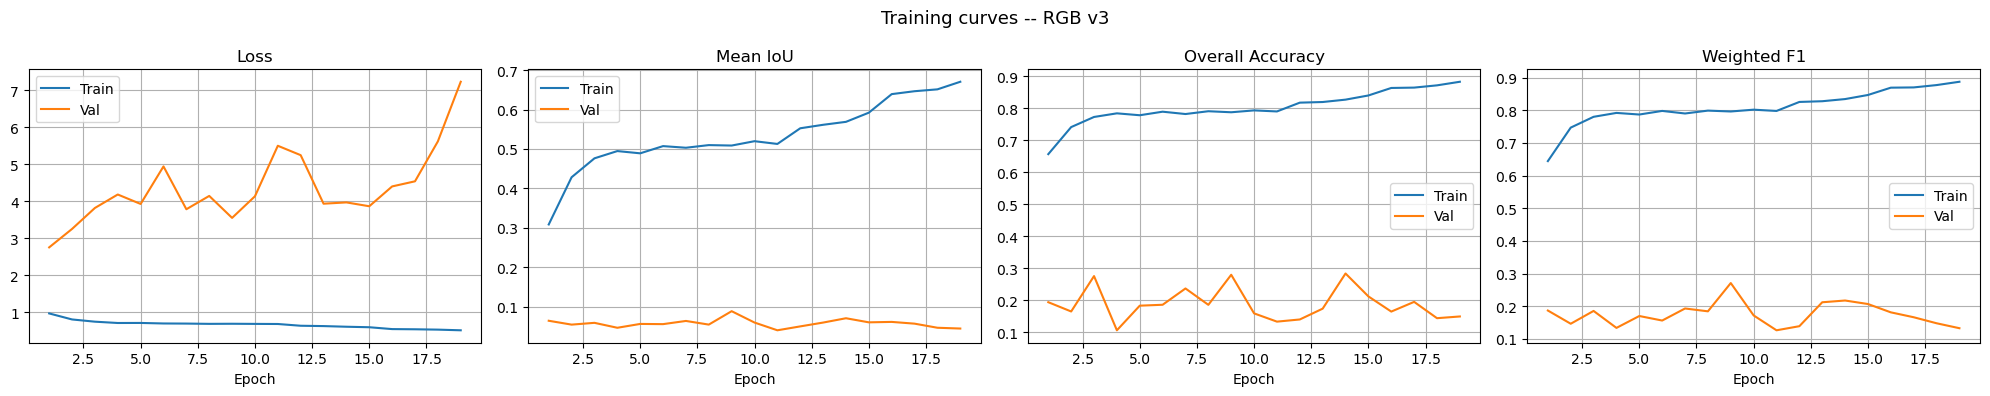

In [25]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, tc, vc, title in zip(
    axes,
    ["train_loss","train_miou","train_oa","train_f1"],
    ["val_loss",  "val_miou",  "val_oa",  "val_f1"],
    ["Loss","Mean IoU","Overall Accuracy","Weighted F1"]
):
    ax.plot(history_df["epoch"], history_df[tc], label="Train")
    ax.plot(history_df["epoch"], history_df[vc], label="Val")
    ax.set_title(title); ax.set_xlabel("Epoch")
    ax.legend(); ax.grid(True)
plt.suptitle(f"Training curves -- {MODALITY.upper()} v3", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"training_curves_{MODALITY}_v3.png", dpi=150)
plt.show()

## 12. Test evaluation

Loaded best model.
  [Test] 200/1269 | loss=4.9931
  [Test] 400/1269 | loss=3.9394
  [Test] 600/1269 | loss=3.8422
  [Test] 800/1269 | loss=4.1895
  [Test] 1000/1269 | loss=4.1327
  [Test] 1200/1269 | loss=3.8389
  [Test] 1269/1269 | loss=3.7097

RESULTS -- RGB v3 -- TEST SET
  Overall Accuracy   : 0.2007
  Mean IoU           : 0.0593
  Weighted F1        : 0.2599
  Weighted Precision : 0.7039
  Weighted Recall    : 0.2007

  Class                     IoU       PA       UA       F1
  -------------------------------------------------------
  Maize                  0.0788   0.6262   0.0827   0.1461
  Maize+Pumpkin          0.0145   0.1216   0.0162   0.0286
  Beans+Maize            0.0000   0.0000   0.0000   0.0000
  Cassava+Maize          0.0000   0.0000   0.0000   0.0000 *
  Grass                  0.1805   0.1857   0.8669   0.3059
  Mixed                  0.0822   0.0942   0.3910   0.1519
  * low-confidence class

Saved -> E:\THESIS_COLLINS HLORDZIE\02_PROCESSED\Models\rgb_v3\confusion_

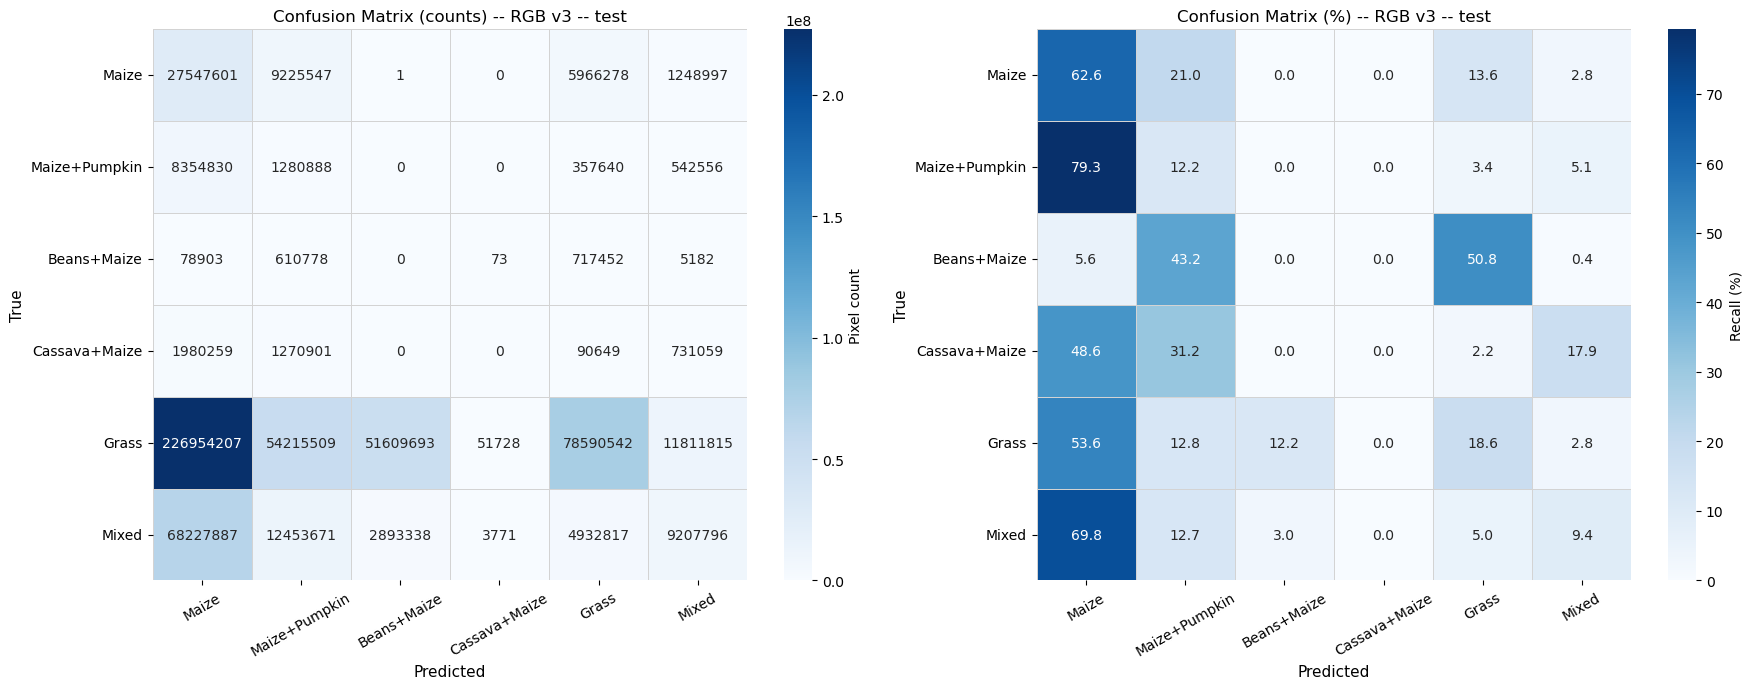

Results saved.


In [26]:
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
print("Loaded best model.", flush=True)
test_metrics = evaluate(model, test_dl, criterion_val, DEVICE, "Test")
print_full_report(test_metrics, CLASS_NAMES, MODALITY, "test")
plot_confusion_matrix(
    test_metrics["conf_matrix"], CLASS_NAMES, MODALITY, "test",
    save_path=OUTPUT_DIR / f"confusion_matrix_{MODALITY}_v3.png"
)
rows = []
for i, name in enumerate(CLASS_NAMES):
    rows.append({"class": name,
                 "iou":   test_metrics["iou_per_class"][i],
                 "PA":    test_metrics["recall_per_class"][i],
                 "UA":    test_metrics["precision_per_class"][i],
                 "f1":    test_metrics["f1_per_class"][i]})
rows.append({"class":"Weighted Avg",
             "iou":test_metrics["miou"],
             "PA":test_metrics["weighted_recall"],
             "UA":test_metrics["weighted_precision"],
             "f1":test_metrics["weighted_f1"]})
rows.append({"class":"Overall Accuracy",
             "iou":test_metrics["overall_acc"],
             "PA":"","UA":"","f1":""})
pd.DataFrame(rows).to_csv(
    OUTPUT_DIR / f"test_results_{MODALITY}_v3.csv", index=False)
print("Results saved.")

## 13. PA / UA diagnostic

In [27]:
cm = test_metrics["conf_matrix"]
print(f"{'='*70}")
print(f"PA / UA -- {MODALITY.upper()} v3 -- TEST")
print(f"{'='*70}")
diag_rows = []
for i, name in enumerate(CLASS_NAMES):
    tp = cm[i,i]; rs = cm[i,:].sum(); cs = cm[:,i].sum()
    fp = cs - tp; fn = rs - tp
    pa  = tp/(rs+1e-6); ua = tp/(cs+1e-6)
    f1  = 2*pa*ua/(pa+ua+1e-6)
    iou = tp/(tp+fp+fn+1e-6)
    if rs == 0:     diag = "NO TRUE PIXELS"
    elif tp == 0:   diag = "NEVER PREDICTED"
    elif pa < 0.10:
        r = cm[i,:].copy(); r[i]=0
        diag = f"LOW PA -> {CLASS_NAMES[r.argmax()]}"
    elif ua < 0.10:
        c2 = cm[:,i].copy(); c2[i]=0
        diag = f"LOW UA -> {CLASS_NAMES[c2.argmax()]} misclassified here"
    else: diag = "OK"
    print(f"  {name:20s}  PA={pa:.4f}  UA={ua:.4f}  "
          f"F1={f1:.4f}  IoU={iou:.4f}  {rs:>12,}px  {diag}")
    diag_rows.append({"Class":name,"PA":round(pa,4),"UA":round(ua,4),
                      "F1":round(f1,4),"IoU":round(iou,4),
                      "True_px":int(rs),"Diagnosis":diag})
diag_df = pd.DataFrame(diag_rows)
diag_df.to_csv(OUTPUT_DIR/f"pa_ua_{MODALITY}_v3.csv", index=False)
display(diag_df)
print("\nConfusion breakdown:")
for i, name in enumerate(CLASS_NAMES):
    rs = cm[i,:].sum()
    if rs == 0: continue
    pct = cm[i,:] / (rs+1e-6) * 100
    print(f"\n  True: {name} ({rs:,} px)")
    for j, cn in enumerate(CLASS_NAMES):
        if pct[j] > 1.0:
            mk = " <-- correct" if i==j else ""
            print(f"    -> {cn:20s} : {pct[j]:5.1f}%{mk}")

PA / UA -- RGB v3 -- TEST
  Maize                 PA=0.6262  UA=0.0827  F1=0.1461  IoU=0.0788    43,988,424px  LOW UA -> Grass misclassified here
  Maize+Pumpkin         PA=0.1216  UA=0.0162  F1=0.0286  IoU=0.0145    10,535,914px  LOW UA -> Grass misclassified here
  Beans+Maize           PA=0.0000  UA=0.0000  F1=0.0000  IoU=0.0000     1,412,388px  NEVER PREDICTED
  Cassava+Maize         PA=0.0000  UA=0.0000  F1=0.0000  IoU=0.0000     4,072,868px  NEVER PREDICTED
  Grass                 PA=0.1857  UA=0.8669  F1=0.3059  IoU=0.1805   423,233,494px  OK
  Mixed                 PA=0.0942  UA=0.3910  F1=0.1519  IoU=0.0822    97,719,280px  LOW PA -> Maize


,Class,PA,UA,F1,IoU,True_px,Diagnosis
0,Maize,0.6262,0.0827,0.1461,0.0788,43988424,LOW UA -> Grass misclassified here
1,Maize+Pumpkin,0.1216,0.0162,0.0286,0.0145,10535914,LOW UA -> Grass misclassified here
2,Beans+Maize,0.0000,0.0000,0.0000,0.0000,1412388,NEVER PREDICTED
3,Cassava+Maize,0.0000,0.0000,0.0000,0.0000,4072868,NEVER PREDICTED
4,Grass,0.1857,0.8669,0.3059,0.1805,423233494,OK
5,Mixed,0.0942,0.3910,0.1519,0.0822,97719280,LOW PA -> Maize



Confusion breakdown:

  True: Maize (43,988,424 px)
    -> Maize                :  62.6% <-- correct
    -> Maize+Pumpkin        :  21.0%
    -> Grass                :  13.6%
    -> Mixed                :   2.8%

  True: Maize+Pumpkin (10,535,914 px)
    -> Maize                :  79.3%
    -> Maize+Pumpkin        :  12.2% <-- correct
    -> Grass                :   3.4%
    -> Mixed                :   5.1%

  True: Beans+Maize (1,412,388 px)
    -> Maize                :   5.6%
    -> Maize+Pumpkin        :  43.2%
    -> Grass                :  50.8%

  True: Cassava+Maize (4,072,868 px)
    -> Maize                :  48.6%
    -> Maize+Pumpkin        :  31.2%
    -> Grass                :   2.2%
    -> Mixed                :  17.9%

  True: Grass (423,233,494 px)
    -> Maize                :  53.6%
    -> Maize+Pumpkin        :  12.8%
    -> Beans+Maize          :  12.2%
    -> Grass                :  18.6% <-- correct
    -> Mixed                :   2.8%

  True: Mixed (97,719,280

## 14. Visualisation — fixed tiles (RGB)

Saves tile list to disk for MS run.

Saved fixed tile list -> E:\THESIS_COLLINS HLORDZIE\02_PROCESSED\Models\fixed_viz_tiles_v3.txt
  3 rare-class tiles, 3 others
Saved -> E:\THESIS_COLLINS HLORDZIE\02_PROCESSED\Models\rgb_v3\viz_test_rgb_v3.png


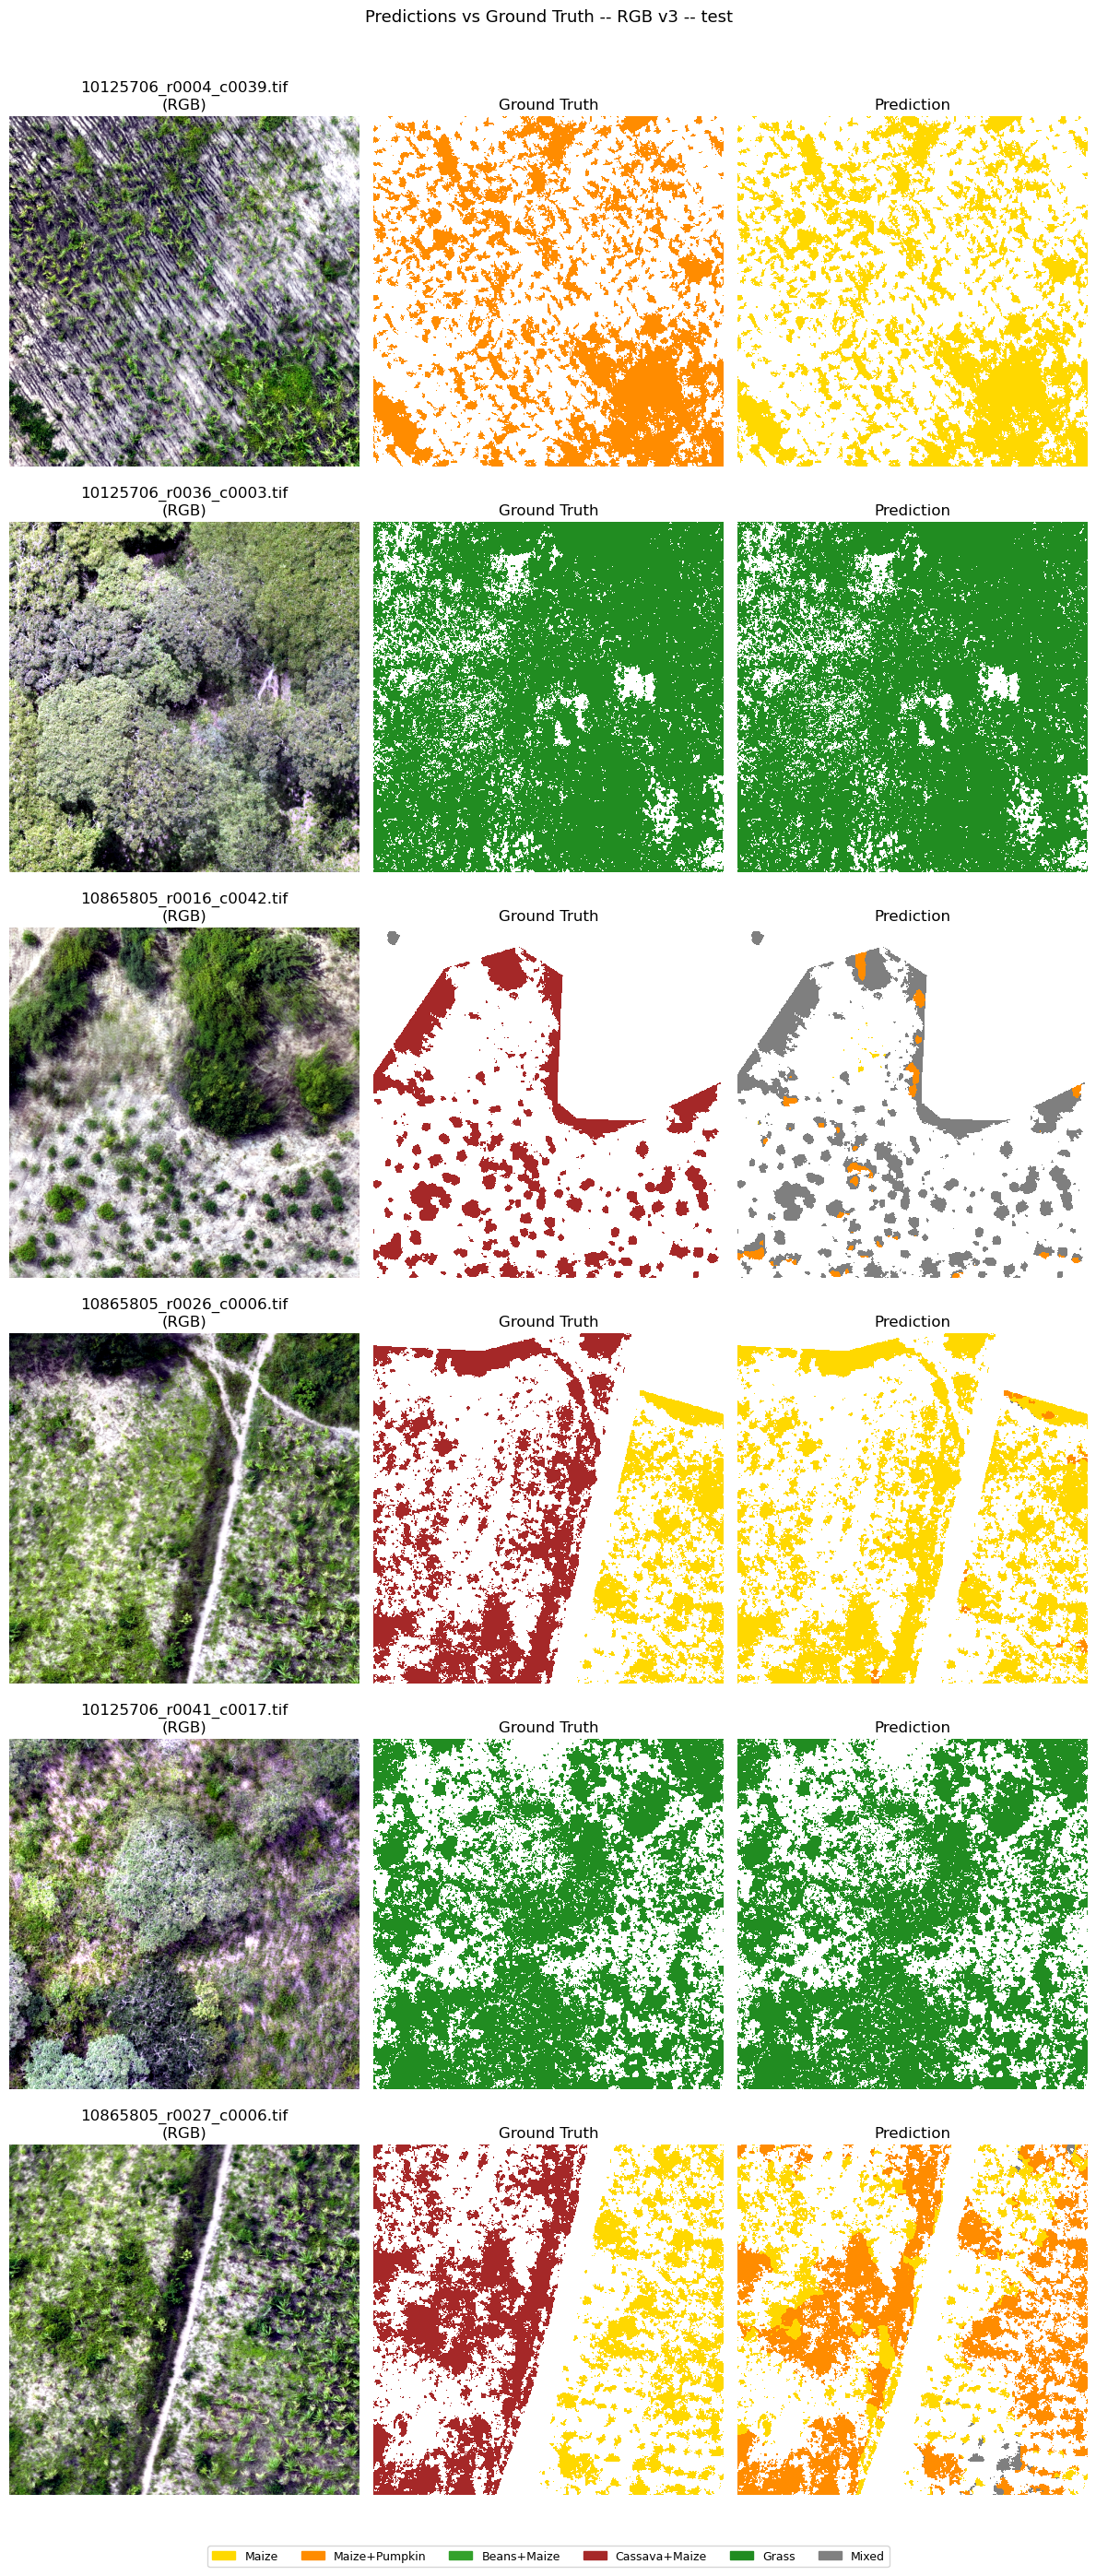

In [28]:
@torch.no_grad()
def visualise_fixed_tiles(model, img_dir, lbl_dir, split,
                          mean, std, device,
                          fixed_tiles_path, n_samples=6,
                          save_path=None, display_mode="rgb"):
    model.eval()
    tile_dir   = Path(img_dir) / split
    lbl_dir_   = Path(lbl_dir) / split
    fixed_path = Path(fixed_tiles_path)

    if fixed_path.exists():
        with open(fixed_path) as f:
            tile_names = [l.strip() for l in f if l.strip()]
        print(f"Loaded {len(tile_names)} fixed tiles from {fixed_path}")
        tile_names = [t for t in tile_names if (tile_dir / t).exists()]
    else:
        all_tiles = sorted(lbl_dir_.glob("*.tif"))
        rare, other = [], []
        for tp in all_tiles:
            with rasterio.open(tp) as src:
                data = src.read(1).ravel()
            classes = set(np.unique(data)) - {IGNORE_INDEX}
            if classes & {2, 3}:
                rare.append(tp.name)
            else:
                other.append(tp.name)
        sel_rare  = random.sample(rare,  min(3, len(rare)))
        sel_other = random.sample(other, min(n_samples - len(sel_rare), len(other)))
        tile_names = sel_rare + sel_other
        random.shuffle(tile_names)
        fixed_path.parent.mkdir(parents=True, exist_ok=True)
        with open(fixed_path, "w") as f:
            for name in tile_names:
                f.write(name + "\n")
        print(f"Saved fixed tile list -> {fixed_path}")
        print(f"  {len(sel_rare)} rare-class tiles, {len(sel_other)} others")

    fig, axes = plt.subplots(len(tile_names), 3,
                             figsize=(12, 4.5 * len(tile_names)))
    if len(tile_names) == 1:
        axes = [axes]

    for row_idx, tile_name in enumerate(tile_names):
        with rasterio.open(tile_dir / tile_name) as src:
            img_raw = src.read().astype(np.float32)
        with rasterio.open(lbl_dir_ / tile_name) as src:
            lbl = src.read(1).astype(np.float32)
        img_norm = img_raw.copy()
        for c in range(img_norm.shape[0]):
            img_norm[c] = (img_norm[c] - mean[c]) / (std[c] + 1e-6)
        tensor = torch.tensor(img_norm).unsqueeze(0).to(device)
        out    = model(pixel_values=tensor)
        lu     = F.interpolate(out.logits, size=(TILE_SIZE, TILE_SIZE),
                               mode="bilinear", align_corners=False)
        pred = lu.argmax(dim=1).squeeze(0).cpu().numpy()
        if display_mode == "cir":
            disp = np.stack([img_raw[2], img_raw[0], img_raw[1]], axis=-1)
            disp_title = "CIR (NIR-Red-Green)"
        else:
            disp = img_raw[:3].transpose(1, 2, 0)
            disp_title = "RGB"
        p2, p98 = (np.percentile(disp, 2, axis=(0,1)),
                   np.percentile(disp, 98, axis=(0,1)))
        disp = np.clip((disp - p2) / (p98 - p2 + 1e-6), 0, 1)
        lbl_d  = np.ma.masked_where(lbl == IGNORE_INDEX, lbl)
        pred_d = np.ma.masked_where(lbl == IGNORE_INDEX, pred)
        ax_img, ax_gt, ax_pred = axes[row_idx]
        ax_img.imshow(disp)
        ax_img.set_title(f"{tile_name}\n({disp_title})")
        ax_img.axis("off")
        ax_gt.imshow(lbl_d, cmap=CMAP, vmin=0,
                     vmax=NUM_CLASSES-1, interpolation="nearest")
        ax_gt.set_title("Ground Truth"); ax_gt.axis("off")
        ax_pred.imshow(pred_d, cmap=CMAP, vmin=0,
                       vmax=NUM_CLASSES-1, interpolation="nearest")
        ax_pred.set_title("Prediction"); ax_pred.axis("off")

    fig.legend(handles=make_legend_patches(), loc="lower center",
               ncol=NUM_CLASSES, bbox_to_anchor=(0.5, -0.02),
               fontsize=9, frameon=True)
    plt.suptitle(
        f"Predictions vs Ground Truth -- {MODALITY.upper()} v3 -- {split}",
        fontsize=13, y=1.01)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved -> {save_path}")
    plt.show()


visualise_fixed_tiles(
    model, IMG_DIR, LBL_DIR, split="test",
    mean=MEAN, std=STD, device=DEVICE,
    fixed_tiles_path=FIXED_TILES_PATH,
    n_samples=6,
    save_path=OUTPUT_DIR / f"viz_test_{MODALITY}_v3.png",
    display_mode="rgb",
)

## 15. Specificity for RGB & MS 

This was a later analysis done after training for both modalities.

In [2]:
from pathlib import Path
import numpy as np
import rasterio
from sklearn.metrics import confusion_matrix

# ── Config ────────────────────────────────────────────────────────────────
BASE_DIR  = Path(r"E:\THESIS_COLLINS HLORDZIE\02_PROCESSED")
PRED_DIR  = BASE_DIR / "Predictions"
TEST_SAS  = ["10125706", "10605304", "10865805"]
IGNORE_INDEX = 255
CLASS_NAMES  = ["Maize","Maize+Pumpkin","Beans+Maize",
                "Cassava+Maize","Grass","Mixed"]

# ── Loop over both models ─────────────────────────────────────────────────
for modality, pred_subdir, pred_suffix in [
    ("RGB", "rgb_v3", "pred_rgb"),
    ("MS",  "ms_v1",  "pred_ms"),
]:
    y_true, y_pred = [], []

    for sa_id in TEST_SAS:
        lbl_path  = BASE_DIR / "Labels" / f"{sa_id}_labels.tif"
        pred_path = PRED_DIR / pred_subdir / f"{sa_id}_{pred_suffix}.tif"

        with rasterio.open(lbl_path)  as s: lbl  = s.read(1).ravel()
        with rasterio.open(pred_path) as s: pred = s.read(1).ravel()

        valid = lbl != IGNORE_INDEX
        y_true.extend(lbl[valid].tolist())
        y_pred.extend(pred[valid].tolist())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    cm = confusion_matrix(y_true, y_pred, labels=list(range(6)))

    print(f"\n{'='*60}")
    print(f"  {modality} MODEL — Per-Class Metrics")
    print(f"{'='*60}")
    print(f"  {'Class':20s}  {'PA':>8}  {'UA':>8}  "
          f"{'Specificity':>12}  {'F1':>8}")
    print(f"  {'-'*58}")

    for i, name in enumerate(CLASS_NAMES):
        TP   = cm[i, i]
        FN   = cm[i, :].sum() - TP          # missed — true but not predicted
        FP   = cm[:, i].sum() - TP          # false alarms — predicted but wrong
        TN   = cm.sum() - TP - FN - FP      # correctly excluded

        PA   = TP / (TP + FN) if (TP + FN) > 0 else 0   # recall
        UA   = TP / (TP + FP) if (TP + FP) > 0 else 0   # precision
        spec = TN / (TN + FP) if (TN + FP) > 0 else 0   # specificity
        f1   = (2 * PA * UA) / (PA + UA) if (PA + UA) > 0 else 0

        print(f"  {name:20s}  {PA:>8.4f}  {UA:>8.4f}  "
              f"{spec:>12.4f}  {f1:>8.4f}")

    print(f"\n  PA = Producer Accuracy (Recall)")
    print(f"  UA = User Accuracy (Precision)")
    print(f"  Specificity = TN / (TN + FP)  [one-vs-rest per class]")


  RGB MODEL — Per-Class Metrics
  Class                       PA        UA   Specificity        F1
  ----------------------------------------------------------
  Maize                   0.7346    0.0878        0.3752    0.1568
  Maize+Pumpkin           0.0583    0.0087        0.8777    0.0152
  Beans+Maize             0.0000    0.0000        0.9165    0.0000
  Cassava+Maize           0.0000    0.0000        1.0000    0.0000
  Grass                   0.1665    0.8992        0.9502    0.2809
  Mixed                   0.0739    0.4506        0.9816    0.1270

  PA = Producer Accuracy (Recall)
  UA = User Accuracy (Precision)
  Specificity = TN / (TN + FP)  [one-vs-rest per class]

  MS MODEL — Per-Class Metrics
  Class                       PA        UA   Specificity        F1
  ----------------------------------------------------------
  Maize                   0.2760    0.1307        0.8497    0.1774
  Maize+Pumpkin           0.3456    0.0334        0.8159    0.0610
  Beans+Maize      